## Proyecto 2 Intoduccion a Los modelos matematicos para el analisis finacnciero


$$ S(t) $$

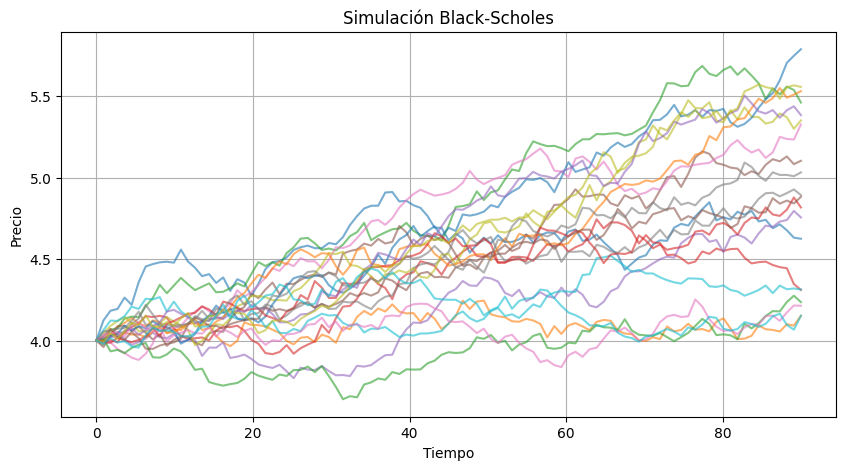

Precio estimado opción ventana: 0.13482970332573313


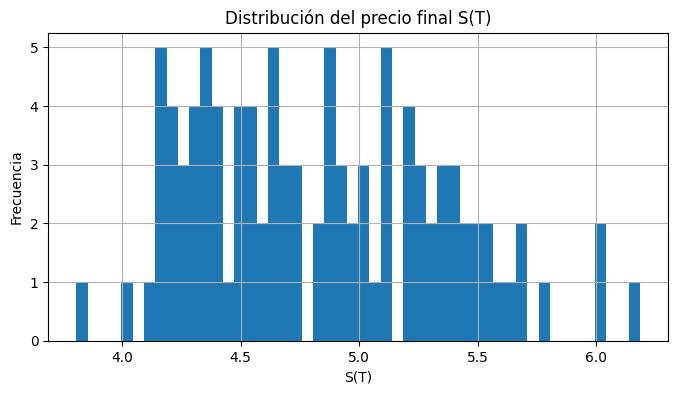

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Función para simular el precio
# -------------------------------
def simular_black_scholes(S0, mu, sigma, T, N, n_sim):
    dt = T / N
    t = np.linspace(0, T, N+1)
    
    # matriz de resultados
    S = np.zeros((n_sim, N+1))
    S[:, 0] = S0
    
    for i in range(1, N+1):
        Z = np.random.normal(0, 1, n_sim)
        S[:, i] = S[:, i-1] + mu*S[:, i-1]*dt + sigma*S[:, i-1]*np.sqrt(dt)*Z
    
    return t, S


# -------------------------------
# 2. Función opción ventana
# -------------------------------
def opcion_ventana_payoff(S_T, E1, E2, E):
    payoff = np.where((S_T >= E1) & (S_T <= E2), np.maximum(S_T - E, 0), 0)
    return payoff


# -------------------------------
# 3. Parámetros
# -------------------------------
S0 = 4
mu = 0.002
sigma = 0.02 # Rene check
T = 90 # Rene Check
N = 100
n_sim = 100

# opción ventana
E1 = 4.5
E2 = 10
E = 5 # 10^3 dolar, 10^ cop
r = 0.001  # tasa libre de riesgo


# -------------------------------
# 4. Simulación
# -------------------------------
t, S = simular_black_scholes(S0, mu, sigma, T, N, n_sim)

# -------------------------------
# 5. Gráfica de trayectorias
# -------------------------------
plt.figure(figsize=(10,5))
for i in range(20):  # solo algunas para no saturar
    plt.plot(t, S[i], alpha=0.6)

plt.title("Simulación Black-Scholes")
plt.xlabel("Tiempo")
plt.ylabel("Precio")
plt.grid()
plt.show()


# -------------------------------
# 6. Precio de la opción ventana (Monte Carlo)
# -------------------------------
S_T = S[:, -1]
payoffs = opcion_ventana_payoff(S_T, E1, E2, E)

# descuento
precio_opcion = np.exp(-r*T) * np.mean(payoffs)

print("Precio estimado opción ventana:", precio_opcion)


# -------------------------------
# 7. Histograma (riesgo)
# -------------------------------
plt.figure(figsize=(8,4))
plt.hist(S_T, bins=50)
plt.title("Distribución del precio final S(T)")
plt.xlabel("S(T)")
plt.ylabel("Frecuencia")
plt.grid()
plt.show()

#### 2a planter BlackScholes



$$
\frac{\partial C}{\partial t}
+
\frac{1}{2}\sigma^2 S^2
\frac{\partial^2 C}{\partial S^2}
+
rS\frac{\partial C}{\partial S}
-
rC
=
0

$$


$$
dS = \mu Sdt + \sigma SdW
$$

#### 2b Condiciones de frontera

$$
C(S_{T},T) = 

\begin{cases}
    max (S_{t} - E,0) & \text{si } E_{1} \le S_{T}\le E_{2} \\
    0   & \text{d.l.c } 
\end{cases}

$$

$$
C(S_{\infty},T) = 0
$$

$$
C(0,T) = 0
$$

#### 2c resolve ecuacion analiticamente

$$
d_{1}(K) = \frac{ln(\frac{S}{K})+(r+\frac{1}{2}\sigma^{2} \tau)}{\sigma \sqrt{\tau}}
$$


$$
d_{2}(K) = \frac{ln(\frac{S}{K})+(r-\frac{1}{2}\sigma^{2} \tau)}{\sigma \sqrt{\tau}}
$$




#### 2c. Transformar la ecuación de Black-Scholes y resolverla analíticamente

La ecuación de Black-Scholes para la opción ventana es:

$$
Sin \ componentes \ aleatorios:
\pi = C - \Delta S

$$
$$
\Delta = \frac{\partial C}{\partial S}


$$

$$
r\pi = \frac{\partial C}{\partial S} + \frac{1}{2} \sigma ^{2} S^{2} \frac{\partial ^{2}C}{\partial S^{2}}
$$

$$


r(C - \frac{\partial C}{\partial S} S) = \frac{\partial C}{\partial S} + \frac{1}{2} \sigma ^{2} S^{2} \frac{\partial ^{2}C}{\partial S^{2}}
$$

$$
0 = \frac{\partial C}{\partial S} + \frac{1}{2} \sigma ^{2} S^{2} + rS\frac{\partial C}{\partial S}  - rC
$$


$$
\frac{\partial C}{\partial t} + \frac{1}{2}\sigma^{2}S^{2}\frac{\partial^{2}C}{\partial S^{2}} + rS\frac{\partial C}{\partial S} - rC = 0
$$

La condición terminal de la opción ventana es:

$$
C(S,T) = \max(S-E,0)\mathbf{1}_{E_{1}\leq S \leq E_{2}}
$$


por simplicidad:

$$
\mathbf{1}_{E_{1}\leq S \leq E_{2}}
=
\begin{cases}
1 & \text{si } E_{1}\leq S \leq E_{2} \\
0 & \text{en otro caso}
\end{cases}
$$

Se realiza el cambio de variables:

$$
x = ln(S)
$$

y:

$$
\tau = T-t
$$

Bajo la medida neutral al riesgo, el activo sigue el proceso:

$$
dS = rSdt + \sigma S dW
$$

La solución del movimiento geométrico browniano es:

$$
S_{T} = S e^{(r-\frac{1}{2}\sigma^{2})(T-t)+\sigma\sqrt{T-t}Z}
$$

donde:

$$
Z \sim N(0,1)
$$

El valor de la opción puede escribirse como:

$$
C(S,t)=e^{-r(T-t)}\mathbb{E}^{Q}\left[\max(S-E,0)\mathbf{1}_{E_{1}\leq S \leq E_{2}}\right]
$$

Definiendo:

$$
L = \max(E,E_{1})
$$

la solución analítica de la call ventana es:

$$
C(S,t)=S\left[N(d_{1}(L))-N(d_{1}(E_{2}))\right]-Ee^{-r(T-t)}\left[N(d_{2}(L))-N(d_{2}(E_{2}))\right]
$$

donde:

$$
d_{1}(K)=\frac{ln(\frac{S}{K})+(r+\frac{1}{2}\sigma^{2})(T-t)}{\sigma\sqrt{T-t}}
$$

$$
d_{2}(K)=d_{1}(K)-\sigma\sqrt{T-t}
$$


$$
d_{2}(K) = \frac{ln(\frac{S}{K})+(r-\frac{1}{2}\sigma^{2} \tau)}{\sigma \sqrt{\tau}}
$$


y:

$$
N(\cdot)
$$

Es la función de distribución acumulada de una normal estándar.

Finalmente, si:

$$
E_{2}\leq E
$$

entonces:

$$
C(S,t)=0
$$

ya que la opción nunca tendría valor intrínseco positivo.

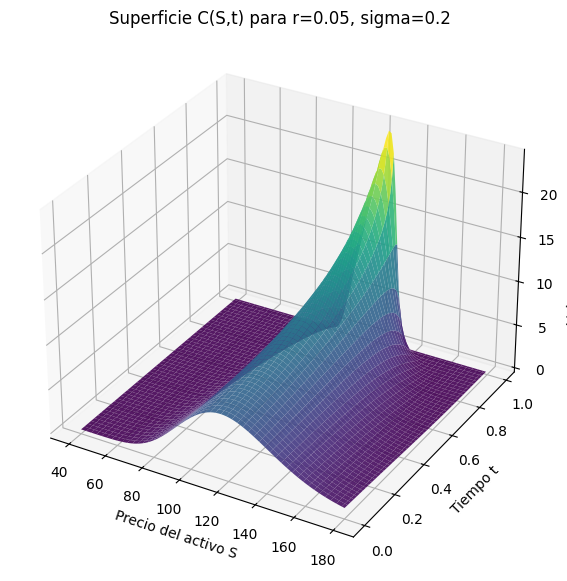

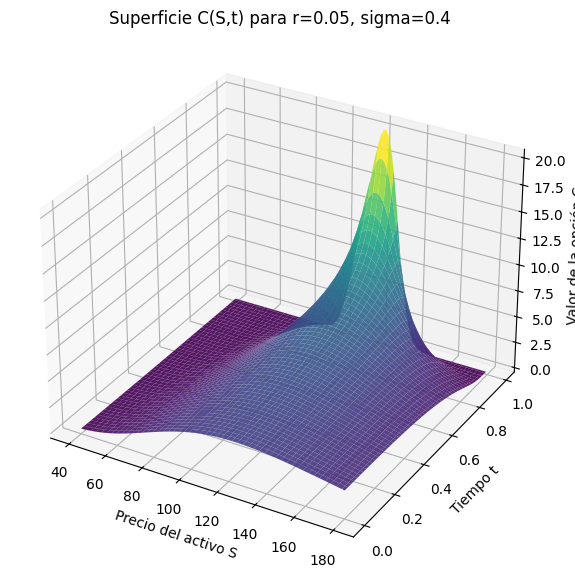

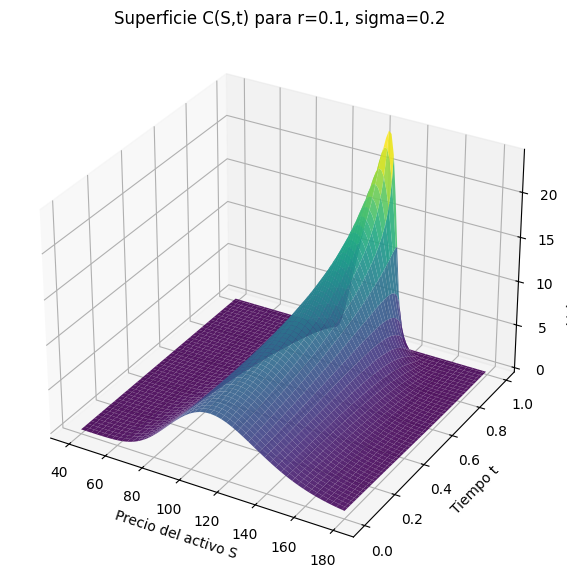

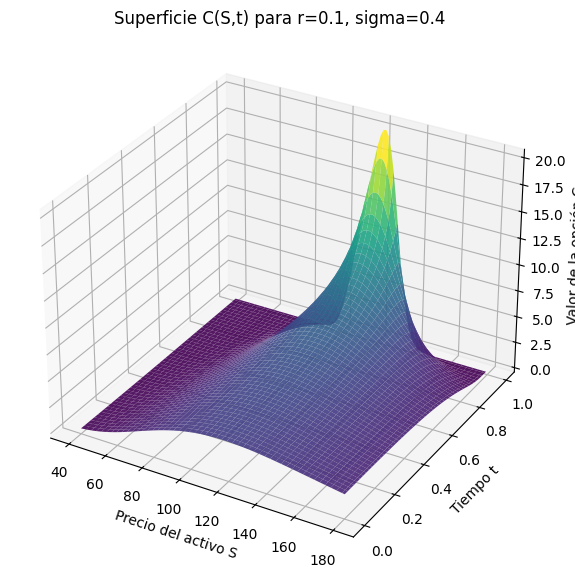

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def call_ventana(S, t, T, E1, E, E2, r, sigma):
    tau = T - t
    C = np.zeros_like(S, dtype=float)

    if E2 <= E:
        return C

    L = max(E, E1)
    mask = tau > 0

    d1_L = (np.log(S[mask] / L) + (r + 0.5 * sigma**2) * tau[mask]) / (sigma * np.sqrt(tau[mask]))
    d2_L = d1_L - sigma * np.sqrt(tau[mask])

    d1_E2 = (np.log(S[mask] / E2) + (r + 0.5 * sigma**2) * tau[mask]) / (sigma * np.sqrt(tau[mask]))
    d2_E2 = d1_E2 - sigma * np.sqrt(tau[mask])

    C[mask] = (
        S[mask] * (norm.cdf(d1_L) - norm.cdf(d1_E2))
        - E * np.exp(-r * tau[mask]) * (norm.cdf(d2_L) - norm.cdf(d2_E2))
    )

    return np.maximum(C, 0)

# Parámetros de la opción
T = 1
E1 = 80
E = 100
E2 = 130

# Rangos para graficar
S_vals = np.linspace(40, 180, 100)
t_vals = np.linspace(0, 0.99, 100)

S_grid, t_grid = np.meshgrid(S_vals, t_vals)

# Casos con diferentes tasas de interés y volatilidades
casos = [
    {"r": 0.05, "sigma": 0.20},
    {"r": 0.05, "sigma": 0.40},
    {"r": 0.10, "sigma": 0.20},
    {"r": 0.10, "sigma": 0.40}
]

# Gráficas de superficie
for caso in casos:
    r = caso["r"]
    sigma = caso["sigma"]

    C_grid = call_ventana(S_grid, t_grid, T, E1, E, E2, r, sigma)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_surface(S_grid, t_grid, C_grid, cmap="viridis", alpha=0.9)

    ax.set_title(f"Superficie C(S,t) para r={r}, sigma={sigma}")
    ax.set_xlabel("Precio del activo S")
    ax.set_ylabel("Tiempo t")
    ax.set_zlabel("Valor de la opción C")

    plt.show()